In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "games.csv",
    nrows=30000,
    engine='python',
    index_col=False
)

In [3]:
#ukuran dataset
print("Jumlah data awal :", df.shape)

Jumlah data awal : (30000, 39)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   AppID                       30000 non-null  int64  
 1   Name                        30000 non-null  str    
 2   Release date                30000 non-null  str    
 3   Estimated owners            30000 non-null  str    
 4   Peak CCU                    30000 non-null  int64  
 5   Required age                30000 non-null  int64  
 6   Price                       30000 non-null  float64
 7   DiscountDLC count           30000 non-null  int64  
 8   About the game              30000 non-null  int64  
 9   Supported languages         27947 non-null  str    
 10  Full audio languages        30000 non-null  str    
 11  Reviews                     30000 non-null  str    
 12  Header image                2917 non-null   str    
 13  Website                     29982 non-null

In [5]:
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...


In [6]:
df.columns

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='str')

In [7]:
#final dataset

kolom_final = [
    'Name',
    'Price',
    'Peak CCU',
    'Required age',
    'DiscountDLC count',
    'Positive',
    'Negative',
    'Recommendations',
    'Estimated owners',
    'Genres'
]

df = df[kolom_final]

df.head()

,Name,Price,Peak CCU,Required age,DiscountDLC count,Positive,Negative,Recommendations,Estimated owners,Genres
0,Black Dragon Mage Playtest,0.00,0,0,0,0,0,0,0 - 0,NaN
1,Supipara - Chapter 1 Spring Has Come!,5.24,0,0,65,0,252,0,0 - 20000,"Single-player,Steam Trading Cards,Steam Cloud,..."
2,Mystery Solitaire The Black Raven,4.99,0,0,0,0,21,0,0 - 20000,"Single-player,Family Sharing"
3,버튜버 파라노이아 - Vtuber Paranoia,8.99,1,0,0,0,0,19,0 - 20000,"Single-player,Steam Achievements,Family Sharing"
4,Maze Quest VR,4.99,0,0,0,0,0,0,0 - 20000,"Single-player,VR Only,Steam Leaderboards,Famil..."


In [8]:
#DATA_WRANGLING

#missing value 
df.isnull().sum()

Name                    0
Price                   0
Peak CCU                0
Required age            0
DiscountDLC count       0
Positive                0
Negative                0
Recommendations         0
Estimated owners        0
Genres               2182
dtype: int64

In [9]:
#isi missing value

#mengisi missing value numerik dengan 0
kolom_numerik = df.select_dtypes(include=np.number).columns
df[kolom_numerik] = df[kolom_numerik].fillna(0)

#mengisi missing value teks dengan 'Unknown'
kolom_teks = df.select_dtypes(include=['object', 'string']).columns
df[kolom_teks] = df[kolom_teks].fillna('Unknown')

In [10]:
#cek duplikat
df.duplicated().sum()

np.int64(2)

In [11]:
#hapus duplikat
df.drop_duplicates(inplace=True)

In [12]:
# membuat total reviews
df['Total Reviews'] = df['Positive'] + df['Negative']

# jumlah data sebelum filter
sebelum = len(df)

# filter game dengan minimal 10 reviews
df = df[df['Total Reviews'] >= 10].copy() # Menghapus game dengan review terlalu sedikit agar analisis lebih stabil dan tidak dipengaruhi noise data
                                          # jumlah data setelah filter  

sesudah = len(df)

print(f"Baris sebelum filter : {sebelum:,}")
print(f"Baris setelah filter : {sesudah:,}")
print(f"Baris dihapus : {sebelum - sesudah:,}")

Baris sebelum filter : 29,998
Baris setelah filter : 12,739
Baris dihapus : 17,259


In [13]:
# memperbaiki nama kolom review
df.rename(columns={
    'Positive': 'Negative Reviews',
    'Negative': 'Positive Reviews'
}, inplace=True)

# membuat total reviews
df['Total Reviews'] = (
    df['Positive Reviews'] +
    df['Negative Reviews']
)

# filter game dengan minimal 10 review
df = df[df['Total Reviews'] >= 10]

# membuat positive rate
df['Positive Rate'] = (
    df['Positive Reviews'] /
    df['Total Reviews']
) * 100

# mengatasi nilai kosong
df['Positive Rate'] = df['Positive Rate'].fillna(0)

# membulatkan angka
df['Positive Rate'] = df['Positive Rate'].round(2)

df.head()

,Name,Price,Peak CCU,Required age,DiscountDLC count,Negative Reviews,Positive Reviews,Recommendations,Estimated owners,Genres,Total Reviews,Positive Rate
1,Supipara - Chapter 1 Spring Has Come!,5.24,0,0,65,0,252,0,0 - 20000,"Single-player,Steam Trading Cards,Steam Cloud,...",252,100.0
2,Mystery Solitaire The Black Raven,4.99,0,0,0,0,21,0,0 - 20000,"Single-player,Family Sharing",21,100.0
6,Armored Brigade II,35.99,8,0,10,0,117,0,0 - 20000,"Single-player,Steam Workshop,Steam Cloud,Famil...",117,100.0
8,Hepta Beats,0.99,0,0,0,0,28,9,0 - 20000,"Single-player,Steam Achievements,Full controll...",28,100.0
9,MUMBA IV: Egypt Jewels,0.59,1,0,0,0,19,100,0 - 20000,"Single-player,Steam Achievements,Full controll...",19,100.0


In [14]:
print("Jumlah data setelah cleaning :", df.shape)

Jumlah data setelah cleaning : (12739, 12)


In [15]:
#STATISTIK DESKRIPTIF

#rata rata tiap variabel/mean
df.mean(numeric_only=True)

Price                   5.117387
Peak CCU              179.765366
Required age            0.286286
DiscountDLC count      19.775414
Negative Reviews        0.069786
Positive Reviews     2542.968679
Recommendations        32.030615
Total Reviews        2543.038465
Positive Rate          99.943631
dtype: float64

In [16]:
#median
df.median(numeric_only=True)

Price                  2.99
Peak CCU               0.00
Required age           0.00
DiscountDLC count      0.00
Negative Reviews       0.00
Positive Reviews      57.00
Recommendations       12.00
Total Reviews         57.00
Positive Rate        100.00
dtype: float64

In [17]:
#modus
df.mode(numeric_only=True)

,Price,Peak CCU,Required age,DiscountDLC count,Negative Reviews,Positive Reviews,Recommendations,Total Reviews,Positive Rate
0,0.0,0,0,0,0,10,0,10,100.0


In [18]:
#variance
df.var(numeric_only=True)

Price                7.861520e+01
Peak CCU             4.392767e+07
Required age         4.647269e+00
DiscountDLC count    9.392261e+02
Negative Reviews     5.898961e+00
Positive Reviews     1.099383e+09
Recommendations      4.945735e+04
Total Reviews        1.099383e+09
Positive Rate        4.116706e+00
dtype: float64

In [19]:
#standard deviation
df.std(numeric_only=True)

Price                    8.866521
Peak CCU              6627.795182
Required age             2.155753
DiscountDLC count       30.646796
Negative Reviews         2.428778
Positive Reviews     33156.947886
Recommendations        222.390091
Total Reviews        33156.942807
Positive Rate            2.028967
dtype: float64

In [20]:
#skewness
df.skew(numeric_only=True)

Price                12.126344
Peak CCU             76.136154
Required age          7.471130
DiscountDLC count     1.139628
Negative Reviews     36.029245
Positive Reviews     38.041107
Recommendations      20.258275
Total Reviews        38.041118
Positive Rate       -37.112999
dtype: float64

In [21]:
#kurtosis
df.kurt(numeric_only=True)

Price                 242.859376
Peak CCU             6606.460588
Required age           54.221296
DiscountDLC count      -0.327950
Negative Reviews     1331.024524
Positive Reviews     1841.935766
Recommendations       434.768657
Total Reviews        1841.936577
Positive Rate        1397.992228
dtype: float64

In [25]:
print("KESIMPULAN STATISTIK DESKRIPTIF")
print()

print(f"Mean Peak CCU : {df['Peak CCU'].mean():.2f}")
print(f"Median Peak CCU : {df['Peak CCU'].median():.2f}")
print()

print(f"Skewness Peak CCU : {df['Peak CCU'].skew():.2f}")
print(f"Kurtosis Peak CCU : {df['Peak CCU'].kurt():.2f}")
print()

print("Distribusi data Peak CCU cenderung tidak normal dan memiliki banyak outlier.")

KESIMPULAN STATISTIK DESKRIPTIF

Mean Peak CCU : 179.77
Median Peak CCU : 0.00

Skewness Peak CCU : 76.14
Kurtosis Peak CCU : 6606.46

Distribusi data Peak CCU cenderung tidak normal dan memiliki banyak outlier.


In [26]:
#ANALISIS KORELASI


#menghitung korelasi
corr = df.corr(numeric_only=True)

corr

,Price,Peak CCU,Required age,DiscountDLC count,Negative Reviews,Positive Reviews,Recommendations,Total Reviews,Positive Rate
Price,1.000000,0.009908,0.037071,-0.075901,-0.002901,0.022588,-0.017516,0.022588,0.003057
Peak CCU,0.009908,1.000000,0.053869,0.001416,-0.000779,0.761234,0.003777,0.761234,0.000753
Required age,0.037071,0.053869,1.000000,0.091920,-0.003816,0.109585,0.007346,0.109585,0.003690
DiscountDLC count,-0.075901,0.001416,0.091920,1.000000,0.001121,0.041376,0.018359,0.041376,0.001287
Negative Reviews,-0.002901,-0.000779,-0.003816,0.001121,1.000000,-0.002128,-0.001989,-0.002055,-0.940076
Positive Reviews,0.022588,0.761234,0.109585,0.041376,-0.002128,1.000000,0.019466,1.000000,0.002096
Recommendations,-0.017516,0.003777,0.007346,0.018359,-0.001989,0.019466,1.000000,0.019466,0.001444
Total Reviews,0.022588,0.761234,0.109585,0.041376,-0.002055,1.000000,0.019466,1.000000,0.002027
Positive Rate,0.003057,0.000753,0.003690,0.001287,-0.940076,0.002096,0.001444,0.002027,1.000000


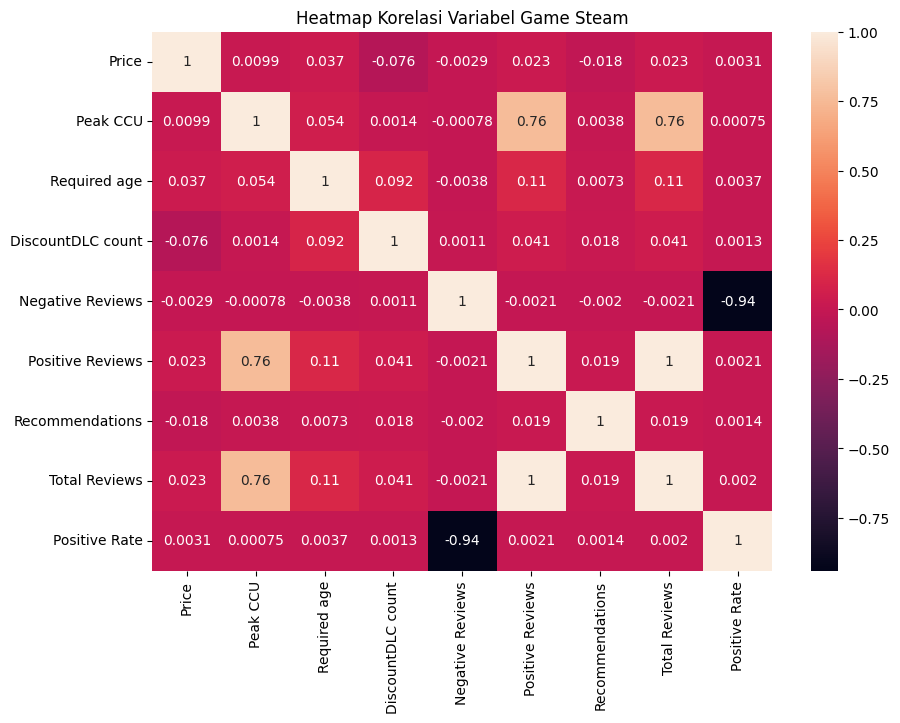

In [27]:
# heatmap korelasi

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap='rocket')

plt.title('Heatmap Korelasi Variabel Game Steam')

plt.show()

In [28]:
print("KESIMPULAN ANALISIS KORELASI")
print()

print(f"Korelasi Peak CCU dengan Positive Reviews : {corr.loc['Peak CCU','Positive Reviews']:.2f}")
print(f"Korelasi Peak CCU dengan Total Reviews    : {corr.loc['Peak CCU','Total Reviews']:.2f}")
print(f"Korelasi Negative Reviews dengan Positive Rate : {corr.loc['Negative Reviews','Positive Rate']:.2f}")

print()
print("Interpretasi:")
print("- Peak CCU memiliki hubungan positif yang cukup kuat terhadap jumlah review.")
print("- Semakin tinggi jumlah pemain aktif, maka total review game cenderung meningkat.")
print("- Negative Reviews memiliki hubungan negatif yang sangat kuat terhadap Positive Rate.")
print("- Harga game memiliki hubungan yang lemah terhadap variabel lain.")
print("- Sebagian besar variabel memiliki korelasi rendah karena karakteristik data game sangat beragam.")

KESIMPULAN ANALISIS KORELASI

Korelasi Peak CCU dengan Positive Reviews : 0.76
Korelasi Peak CCU dengan Total Reviews    : 0.76
Korelasi Negative Reviews dengan Positive Rate : -0.94

Interpretasi:
- Peak CCU memiliki hubungan positif yang cukup kuat terhadap jumlah review.
- Semakin tinggi jumlah pemain aktif, maka total review game cenderung meningkat.
- Negative Reviews memiliki hubungan negatif yang sangat kuat terhadap Positive Rate.
- Harga game memiliki hubungan yang lemah terhadap variabel lain.
- Sebagian besar variabel memiliki korelasi rendah karena karakteristik data game sangat beragam.


In [34]:
#VISUALISASI

df['Peak CCU'].describe()


count     12739.000000
mean        179.765366
std        6627.795182
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max      623941.000000
Name: Peak CCU, dtype: float64

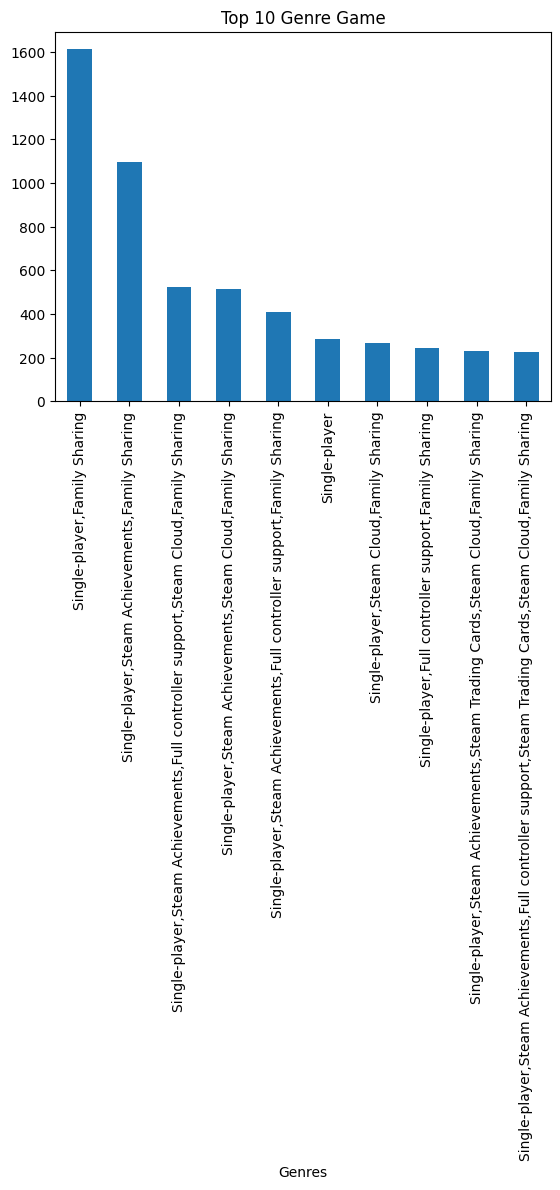

In [35]:
top_genre = df['Genres'].value_counts().head(10)

top_genre.plot(kind='bar')

plt.title('Top 10 Genre Game')

plt.show()

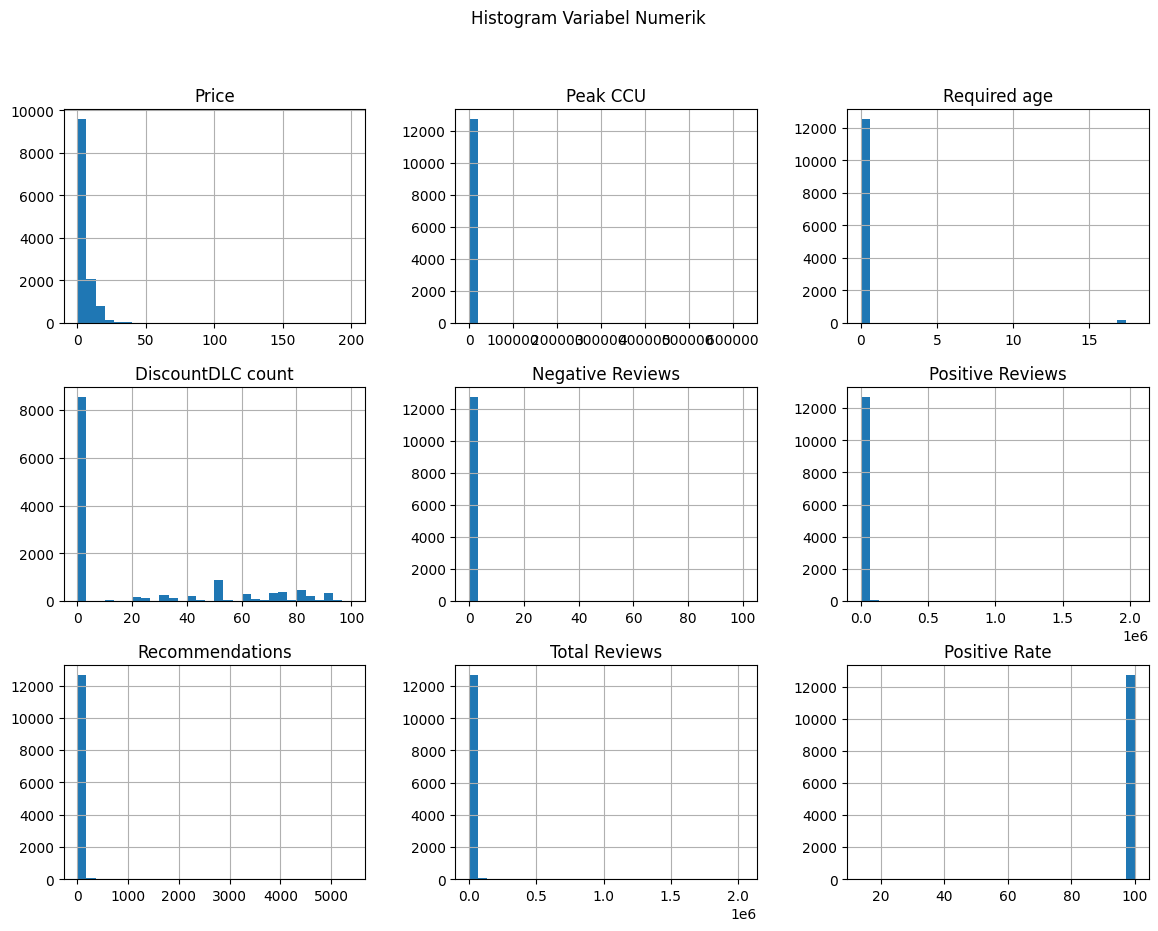

In [36]:
# histogram

df.hist(figsize=(14,10), bins=30)

plt.suptitle('Histogram Variabel Numerik')

plt.show()

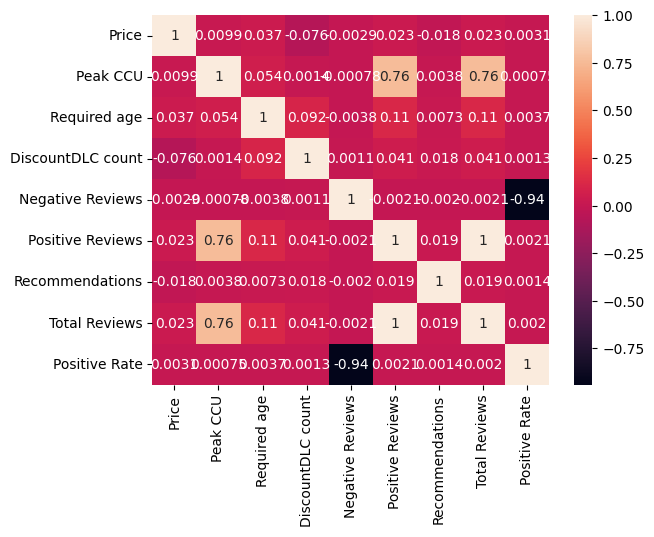

In [37]:
#heatmap korelasi
sns.heatmap(corr, annot=True)
plt.show()

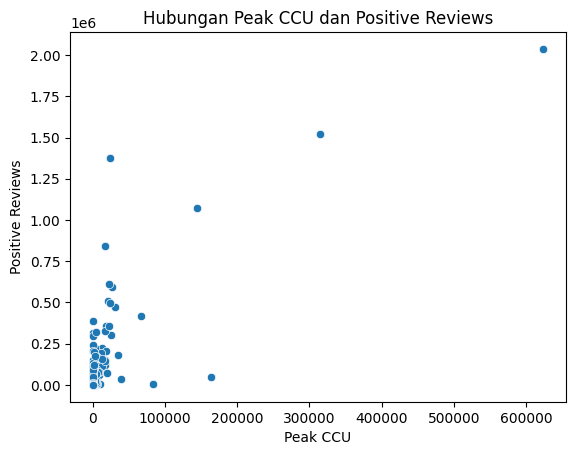

In [39]:
#scatterplot Peak CCU vs Positive Reviews

sns.scatterplot(
    data=df,
    x='Peak CCU',
    y='Positive Reviews'
)

plt.title('Hubungan Peak CCU dan Positive Reviews')

plt.show()

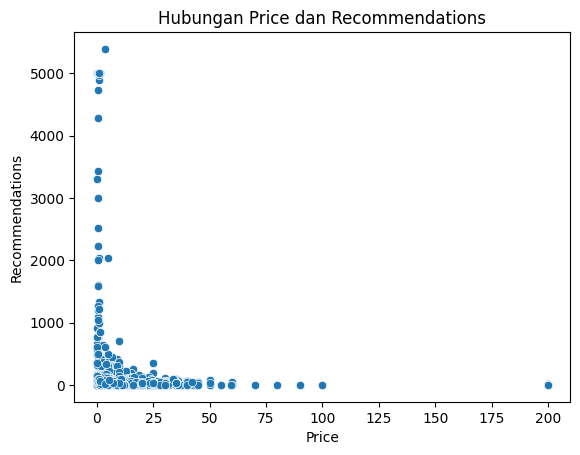

In [40]:
#scatterplot Price vs Recommendations

sns.scatterplot(
    data=df,
    x='Price',
    y='Recommendations'
)

plt.title('Hubungan Price dan Recommendations')

plt.show()

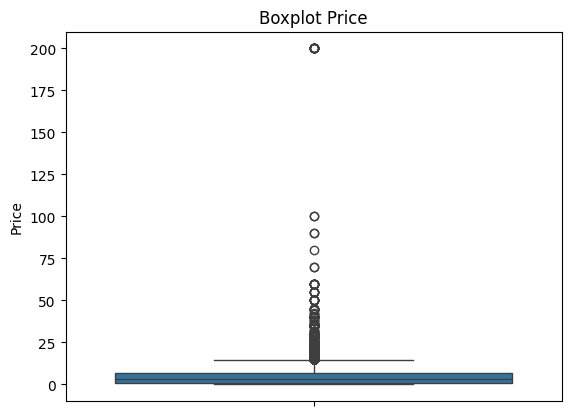

In [41]:
#boxplot Price

sns.boxplot(y=df['Price'])

plt.title('Boxplot Price')

plt.show()

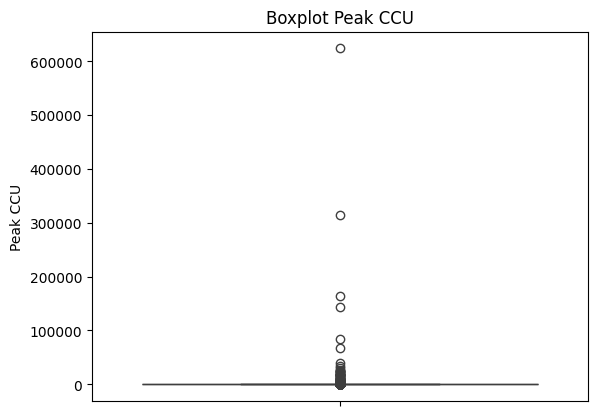

In [42]:
# boxplot Peak CCU

sns.boxplot(y=df['Peak CCU'])

plt.title('Boxplot Peak CCU')

plt.show()

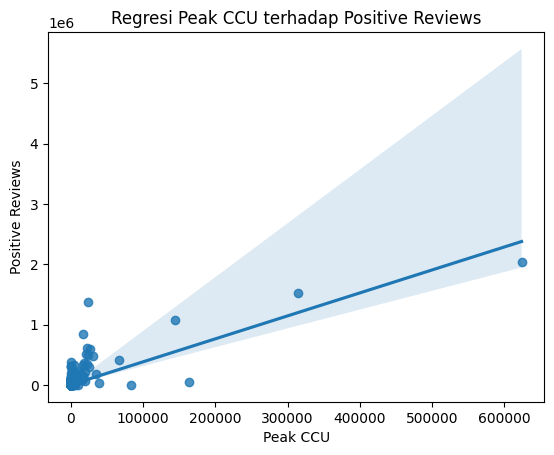

In [43]:
# regresi pertama: Peak CCU terhadap Positive Reviews

sns.regplot(
    data=df,
    x='Peak CCU',
    y='Positive Reviews'
)

plt.title('Regresi Peak CCU terhadap Positive Reviews')

plt.show()

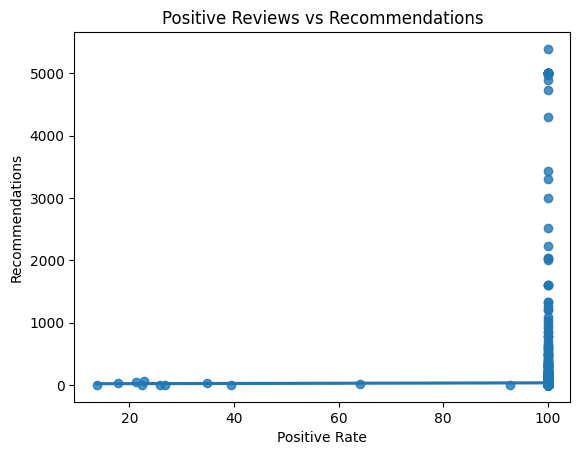

In [44]:
# regresi kedua: Positive Rate terhadap Recommendations

sns.regplot(
    data=df,
    x='Positive Rate',
    y='Recommendations'
)

plt.title('Positive Reviews vs Recommendations')

plt.show()